In [302]:
import pandas as pd
from textblob import TextBlob
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,f1_score
from sklearn.metrics import confusion_matrix


In [303]:
df_kaggle = pd.read_excel("10kTrainingData.xlsx",sheet_name="10kAllCol")
df_kaggle.head()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score
0,comment,imlddn9,2qh3l,news,False,1661990368,https://old.reddit.com/r/news/comments/x2cszk/...,Yeah but what the above commenter is saying is...,0.5719,2
1,comment,imld0kj,2qh1i,askreddit,False,1661990206,https://old.reddit.com/r/AskReddit/comments/x2...,I think climate change tends to get some peopl...,0.6634,1
2,comment,imlctri,3l2gt,walkaway,False,1661990120,https://old.reddit.com/r/walkaway/comments/x2m...,Naaa how could anyone be mad at a face like th...,0.2500,1
3,comment,imlctc0,2vvve,pastors,False,1661990114,https://old.reddit.com/r/pastors/comments/x2il...,Can i suggest maybe honing in on LGBTQ?\n\nIt'...,0.9779,2
4,comment,imlcpab,2qh1i,askreddit,False,1661990065,https://old.reddit.com/r/AskReddit/comments/x2...,They need to change laws so it's more worth se...,0.4690,2


In [304]:
df_crawl = pd.read_excel("full_labeled_dataset.xlsx")
df_crawl.head()

,comment,label
0,I’ll believe it when the climate activists wri...,NEGATIVE
1,Yeah we’re all gonna die. Not cause of climate...,NEGATIVE
2,I think climate change is the next big societa...,POSITIVE
3,She could single handely end Climate Change,NEGATIVE
4,"Yeah, at this point carbon capture seems to be...",NEGATIVE


In [305]:
df_eval = pd.read_excel("eval.xlsx")
df_eval.head()

,comment,label
0,1. How can I know you didn't just make this up...,NEGATIVE
1,"It was never a question of ""Will climate chang...",NEGATIVE
2,Climate change is pretty evident. People are s...,NEGATIVE
3,Climate Change is not an On/Off Climate Change...,NEGATIVE
4,We have been fooling ourselves for the last 40...,NEGATIVE


In [306]:
df_kaggle = df_kaggle[["body", "sentiment"]]

df_kaggle = df_kaggle.rename(columns={"body": "comment"})

def score_to_label(score):
    if score > 0.1:
        return "POSITIVE"
    elif score < -0.1:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df_kaggle["label"] = df_kaggle["sentiment"].apply(score_to_label)
df_kaggle = df_kaggle[["comment", "label"]]
df_kaggle["label"].value_counts()


label
NEGATIVE    4300
POSITIVE    4254
NEUTRAL     1446
Name: count, dtype: int64

In [307]:
df_crawl_train = df_crawl[~df_crawl["comment"].isin(df_eval["comment"])].copy()
overlap = set(df_crawl_train["comment"]).intersection(set(df_eval["comment"]))
print("Overlap:", len(overlap))

Overlap: 0


In [308]:
df_train = pd.concat([
    df_crawl_train,
    df_kaggle
]).dropna().reset_index(drop=True)

df_train = df_train.drop_duplicates(subset="comment")

In [309]:
print("Training size:", len(df_train))
print(df_train["label"].value_counts())

print("Eval size:", len(df_eval))
print(df_eval["label"].value_counts())

Training size: 11058
label
NEGATIVE    5136
POSITIVE    4277
NEUTRAL     1645
Name: count, dtype: int64
Eval size: 1000
label
NEGATIVE    400
POSITIVE    400
NEUTRAL     200
Name: count, dtype: int64


Training Model

In [310]:
def get_features(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df_train[["polarity", "subjectivity"]] = df_train["comment"].apply(
    lambda x: pd.Series(get_features(x))
)
df_eval[["polarity", "subjectivity"]] = df_train["comment"].apply(
    lambda x: pd.Series(get_features(x))
)

In [311]:

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])

model = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=5000))
])



In [312]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df_train[["comment", "polarity", "subjectivity"]]
y = df_train["label"]

# 🔥 Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 🔹 Accuracy
scores_acc = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

# 🔹 F1-score
scores_f1 = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

print("Stratified CV Accuracy scores:", scores_acc)
print("Mean CV Accuracy:", scores_acc.mean())

print("Stratified CV F1 scores:", scores_f1)
print("Mean CV F1:", scores_f1.mean())

Stratified CV Accuracy scores: [0.69303797 0.68625678 0.67676311 0.68611488 0.71551334]
Mean CV Accuracy: 0.6915372177416387
Stratified CV F1 scores: [0.63300403 0.62502571 0.62718936 0.62884137 0.65655225]
Mean CV F1: 0.6341225438930633


In [313]:
model.fit(df_train[["comment", "polarity", "subjectivity"]],df_train["label"])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

Evaluation

Random sample accuracy: 0.455


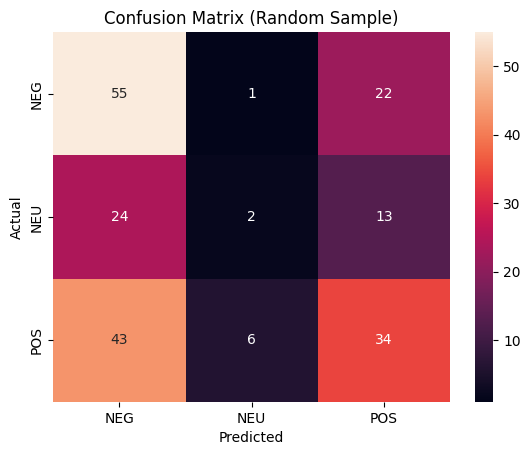

In [314]:

sample = df_eval.sample(n=200, random_state=42)


pred_sample = model.predict(
    sample[["comment", "polarity", "subjectivity"]]
)

acc_sample = accuracy_score(sample["label"], pred_sample)

print("Random sample accuracy:", acc_sample)

cm_sample = confusion_matrix(sample["label"], pred_sample)


plt.figure()
sns.heatmap(
    cm_sample,
    annot=True,
    fmt="d",
    xticklabels=["NEG", "NEU", "POS"],
    yticklabels=["NEG", "NEU", "POS"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Sample)")
plt.show()

In [315]:
import time


start = time.time()

pred = model.predict(
    df_eval[["comment", "polarity", "subjectivity"]]
)


end = time.time()

time_taken = end - start
records_per_sec = len(df_eval) / time_taken

print("Time taken:", time_taken)
print("Records per second:", records_per_sec)

Time taken: 0.06345677375793457
Records per second: 15758.758928001142


Question 5 Ensemble Method + Stacking

To improve the performance of the sentiment classification system, several enhancement were explored beyond the baseline model
1. Experimentation on max_features
2. Enhancement beyond unigram to be able to regonise 2 words such as "not good"
3. Ensemble Classification using stacking.


In [316]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier

In [317]:
X_train = df_train[["comment", "polarity", "subjectivity"]]
y_train = df_train["label"]

X_eval = df_eval[["comment", "polarity", "subjectivity"]]
y_eval = df_eval["label"]

In [318]:
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    
    pred = model.predict(X_eval)
    
    acc = accuracy_score(y_eval, pred)
    f1 = f1_score(y_eval, pred, average="macro")
    
    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")
    
    return acc, f1

Baseline model, max_feature experiment

In [319]:
pre = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=5000, ngram_range=(1,1)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])
        
base_model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=5000))
])


acc_base, f1_base = evaluate_model(base_model, "MaxFeature-grams")

MaxFeature-grams → Accuracy: 0.4690, F1: 0.3615


In [320]:
def experiment_max_features(start=1000, end=30000, step=1000):

    
    results = []
    
    for mf in range(start, end + 1, step):
        pre = ColumnTransformer([
            ("text", TfidfVectorizer(max_features=mf, ngram_range=(1,1)), "comment"),
            ("num", "passthrough", ["polarity", "subjectivity"])
        ])
        
        model = Pipeline([
            ("pre", pre),
            ("clf", LogisticRegression(max_iter=5000))
        ])
        
        # train
        model.fit(X_train, y_train)
        
        # predict
        pred = model.predict(X_eval)
        
        # metrics
        acc = accuracy_score(y_eval, pred)
        f1 = f1_score(y_eval, pred, average="macro")
        
        print(f"max_features={mf} → Acc: {acc:.4f}, F1: {f1:.4f}")
        
        results.append({
            "max_features": mf,
            "Accuracy": acc,
            "F1": f1
        })
    
    df_results = pd.DataFrame(results)
    
    return df_results

In [321]:
df_features = experiment_max_features(1000, 30000, 1000)
print(df_features)

max_features=1000 → Acc: 0.4530, F1: 0.3541
max_features=2000 → Acc: 0.4670, F1: 0.3597
max_features=3000 → Acc: 0.4710, F1: 0.3629
max_features=4000 → Acc: 0.4700, F1: 0.3649
max_features=5000 → Acc: 0.4690, F1: 0.3615
max_features=6000 → Acc: 0.4710, F1: 0.3626
max_features=7000 → Acc: 0.4690, F1: 0.3614
max_features=8000 → Acc: 0.4660, F1: 0.3609
max_features=9000 → Acc: 0.4690, F1: 0.3609
max_features=10000 → Acc: 0.4700, F1: 0.3621
max_features=11000 → Acc: 0.4730, F1: 0.3642
max_features=12000 → Acc: 0.4720, F1: 0.3634
max_features=13000 → Acc: 0.4730, F1: 0.3642
max_features=14000 → Acc: 0.4730, F1: 0.3662
max_features=15000 → Acc: 0.4750, F1: 0.3681
max_features=16000 → Acc: 0.4750, F1: 0.3656
max_features=17000 → Acc: 0.4750, F1: 0.3680
max_features=18000 → Acc: 0.4750, F1: 0.3680
max_features=19000 → Acc: 0.4740, F1: 0.3668
max_features=20000 → Acc: 0.4720, F1: 0.3653
max_features=21000 → Acc: 0.4720, F1: 0.3654
max_features=22000 → Acc: 0.4670, F1: 0.3592
max_features=23000 

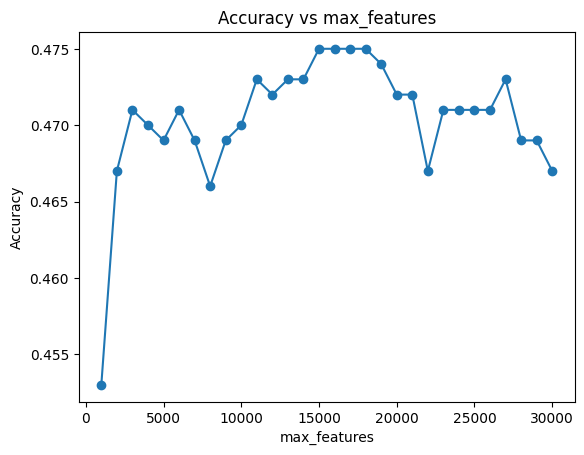

In [322]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_features["max_features"], df_features["Accuracy"], marker='o')
plt.title("Accuracy vs max_features")
plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.show()

Final Max_feature value = 15000

In [323]:
pre = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=15000, ngram_range=(1,1)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])
        
model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=5000))
])


acc_mf, f1_mf = evaluate_model(model, "MaxFeature-grams")

MaxFeature-grams → Accuracy: 0.4750, F1: 0.3681


ngram model

In [324]:
pre_ngram = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=15000, ngram_range=(1,2)), "comment"),
    ("num", "passthrough", ["polarity", "subjectivity"])
])

model_lr = Pipeline([
    ("pre", pre_ngram),
    ("clf", LogisticRegression(max_iter=5000))
])

acc_ngram, f1_ngram = evaluate_model(model_lr, "N-grams")

N-grams → Accuracy: 0.4830, F1: 0.3683


In [325]:
# Naive Bayes Model
model_nb = Pipeline([
    ("pre", ColumnTransformer([
        ("text", TfidfVectorizer(max_features=15000), "comment")
    ])),
    ("clf", MultinomialNB())
])

# SVM Model
model_svm = Pipeline([
    ("pre", preprocessor),
    ("clf", LinearSVC())
])

In [326]:
stack_all = StackingClassifier(
    estimators=[
        ("lr", model_lr),
        ("nb", model_nb),
        ("svm", model_svm)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

acc_stack, f1_stack = evaluate_model(stack_all, "Stacking (All)")

Stacking (All) → Accuracy: 0.4720, F1: 0.3625


In [327]:
stack_lr_nb = StackingClassifier(
    estimators=[("lr", model_lr), ("nb", model_nb)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_lr_svm = StackingClassifier(
    estimators=[("lr", model_lr), ("svm", model_svm)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_nb_svm = StackingClassifier(
    estimators=[("nb", model_nb), ("svm", model_svm)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

acc_lr_nb, f1_lr_nb = evaluate_model(stack_lr_nb, "LR + NB")
acc_lr_svm, f1_lr_svm = evaluate_model(stack_lr_svm, "LR + SVM")
acc_nb_svm, f1_nb_svm = evaluate_model(stack_nb_svm, "NB + SVM")

LR + NB → Accuracy: 0.4820, F1: 0.3733
LR + SVM → Accuracy: 0.4720, F1: 0.3629
NB + SVM → Accuracy: 0.4710, F1: 0.3612


In [328]:
results = pd.DataFrame({
    "Model": [
        "Baseline (5K MaxFeature)",
        "15k Max Feature",
        "N-grams",
        "LR + NB",
        "LR + SVM",
        "NB + SVM",
        "All (LR + NB + SVM)"
    ],
    "Accuracy": [
        acc_base,
        acc_mf,
        acc_ngram,
        acc_lr_nb,
        acc_lr_svm,
        acc_nb_svm,
        acc_stack
    ],
    "F1": [
        f1_base,
        f1_mf,
        f1_ngram,
        f1_lr_nb,
        f1_lr_svm,
        f1_nb_svm,
        f1_stack
    ]
})

print(results)

                      Model  Accuracy        F1
0  Baseline (5K MaxFeature)     0.469  0.361535
1           15k Max Feature     0.475  0.368097
2                   N-grams     0.483  0.368252
3                   LR + NB     0.482  0.373295
4                  LR + SVM     0.472  0.362913
5                  NB + SVM     0.471  0.361171
6       All (LR + NB + SVM)     0.472  0.362522
